
***
<center><h1> Analysing the Macaronesian Chlorophyll System </h1></center>

***


# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
- [3. Data](#3.-Data)
    - [3.1 Presentation of the product used](#3.1-Presentation-of-the-product-used)
    - [3.2 Accessing the data](#3.2-Accessing-the-data)
- [4. Seasonal Patterns of Chlorophyll and Phytoplankton](#4.-Seasonal-Patterns-of-Chlorophyll-and-Phytoplankton)
- [5. Long-term Variation](#5.-Long-term-Variation)
- [6. Vertical Variation](#6.-Vertical-Variation)
- [7. Correlations between chlorophyll and phytoplankton](#7.-Correlations-between-chlorophyll-and-phytoplankton)

# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The notebook analyses the chlorophyll *a* and phytoplankton in the European Macaronesia Area.

 We analyse how these variables vary spatially and seasonally, what are the long-term trends associated with them, and how they vary with depth.

# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

In [2]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime
import pandas as pd
import os

from scipy.stats import linregress, pearsonr
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 3. Data

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)


----------------
Product used 
Global Ocean Biogeochemistry Hindcast  https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/services
https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description
Monthly  01/01/1993–01/11/2025
id: cmems_mod_glo_bgc_my_0.25deg_P1M-m
https://documentation.marine.copernicus.eu/PUM/CMEMS-GLO-PUM-001-029.pdf




In [4]:
import copernicusmarine

**Coordinates AREA**

In [3]:
# In this sell, we define the boundaries of our area of interest

lat_min = 25
lat_max = 41
lon_min = -33
lon_max = -12



***Coordinates AZORES***

In [5]:
lat_minAzores = 35
lat_maxAzores = 41
lon_minAzores = -33
lon_maxAzores = -21

***Coordinates MADEIRA***

In [6]:
lat_minMadeira = 31
lat_maxMadeira = 35
lon_minMadeira = -21
lon_maxMadeira = -13

***Coordinates CANARY ISLANDS***

In [7]:
lat_minCanary = 26
lat_maxCanary = 31
lon_minCanary = -21
lon_maxCanary = -12

## 3.2 Accessing the data

[Go back to the "Table of contents"](#Table-of-contents)

In [ ]:

ChlorPhytoMacaronesia1993_2025 = copernicusmarine.open_dataset(
dataset_id="cmems_mod_glo_bgc_my_0.25deg_P1M-m",  
 variables=["chl", "phyc"],                    
 minimum_longitude=lon_min,
 maximum_longitude=lon_max,
 minimum_latitude=lat_min,
 maximum_latitude=lat_max,
 start_datetime="1993-01-01T00:00:00",
 end_datetime="2025-11-01T00:00:00",
#output_directory = "data"
)

INFO - 2026-02-26T00:22:51Z - Selected dataset version: "202406"
INFO - 2026-02-26T00:22:51Z - Selected dataset part: "default"


In [ ]:
ChlorPhytoMacaronesia1993_2025.to_netcdf("ChlorPhytoMacaronesia1993_2025.nc")

In [6]:
ds = ChlorPhytoMacaronesia1993_2025

In [ ]:
#or
#ds = xr.open_dataset(ChlorPhytoMacaronesia1993_2025.nc)

In [10]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (depth: 75, latitude: 65, longitude: 85, time: 395)
Coordinates:
  * depth      (depth) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * latitude   (latitude) float32 260B 25.0 25.25 25.5 25.75 ... 40.5 40.75 41.0
  * longitude  (longitude) float32 340B -33.0 -32.75 -32.5 ... -12.25 -12.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-11-01
Data variables:
    chl        (time, depth, latitude, longitude) float32 655MB dask.array<chunksize=(144, 50, 64, 64), meta=np.ndarray>
    phyc       (time, depth, latitude, longitude) float32 655MB dask.array<chunksize=(144, 50, 64, 64), meta=np.ndarray>
Attributes:
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    contact:      servicedesk.cmems@mercator-ocean.eu
    Conventions:  CF-1.6
    references:   http://marine.copernicus.eu
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_BIO_001_029
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    source:       MERCATOR FREEBIORYS2V4
    institution:  Mercator Ocean

In [ ]:
ds = ds.isel(depth=slice(0,30))

# 4. Seasonal Patterns of Chlorophyll and Phytoplankton
[Go back to the "Table of contents"](#Table-of-contents)



In [ ]:
#ds = xr.open_dataset('ChlorPhytoMacaronesia1993_2025.nc')
#ds

<xarray.Dataset> Size: 1GB
Dimensions:    (depth: 75, latitude: 65, longitude: 85, time: 395)
Coordinates:
  * depth      (depth) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * latitude   (latitude) float32 260B 25.0 25.25 25.5 25.75 ... 40.5 40.75 41.0
  * longitude  (longitude) float32 340B -33.0 -32.75 -32.5 ... -12.25 -12.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-11-01
Data variables:
    chl        (time, depth, latitude, longitude) float32 655MB ...
    phyc       (time, depth, latitude, longitude) float32 655MB ...
Attributes:
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_BIO_001_029
    Conventions:  CF-1.6
    source:       MERCATOR FREEBIORYS2V4
    institution:  Mercator Ocean
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    references:   http://marine.copernicus.eu
    credit:       E.U. Copernicus Marine Service Information (CMEMS)

In order to highlight seasonal patterns, we can compute 4 different climatologies over 30 years of data available : for Summer, Fall, Winter and Spring. In order to do this, we compute the seasonal means of the dataset using the **groupby** function. Xarray will automatically group together winter months, summer months, etc.

In [10]:
ds_seas = ds.groupby("time.season").mean()
ds_seas

<xarray.Dataset> Size: 13MB
Dimensions:    (season: 4, depth: 75, latitude: 65, longitude: 85)
Coordinates:
  * depth      (depth) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * latitude   (latitude) float32 260B 25.0 25.25 25.5 25.75 ... 40.5 40.75 41.0
  * longitude  (longitude) float32 340B -33.0 -32.75 -32.5 ... -12.25 -12.0
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    chl        (season, depth, latitude, longitude) float32 7MB 0.05374 ... nan
    phyc       (season, depth, latitude, longitude) float32 7MB 0.722 ... nan
Attributes:
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_BIO_001_029
    Conventions:  CF-1.6
    source:       MERCATOR FREEBIORYS2V4
    institution:  Mercator Ocean
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    references:   http://marine.copernicus.eu
    credit:       E.U. Copernicus Marine Service Information (CMEMS)

The time coordinate has been replaced by a "season" coordinate, with 4 values : DJF (December Janury February : Winter), JJA (June July August : Summer), MAM (March April May : Spring), SON (September October November  : Fall).

Lets visualize the computed climatologies.

**Chlorophyll *a***

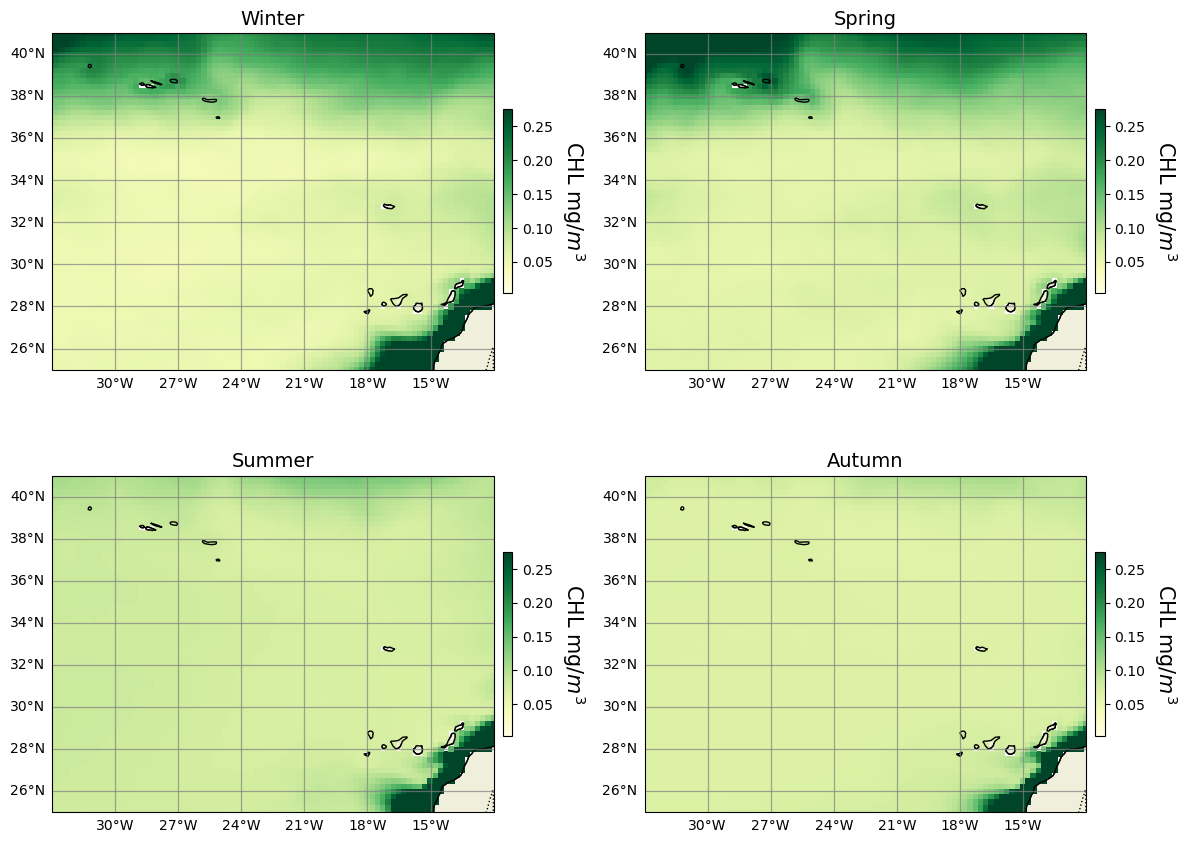

In [ ]:
f = plt.figure(figsize=(12,9))


seasons = ["DJF", "MAM", "JJA", "SON"]
# Dictionary seasons
seasons_name = {
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Autumn'
}
seasons = list(seasons_name.keys())

vmin = np.nanpercentile(ds_seas["chl"].data, 2)  # 2th percentile
vmax = np.nanpercentile(ds_seas["chl"].data, 98)  # 98th percentile

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')                            #'w', facecolor=
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.9, color='gray', alpha=0.7)
    gl.right_labels = False                                                            
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas.longitude.data, ds_seas.latitude.data, ds_seas['chl'].sel(season=season).sel(depth=0, method="nearest").data, cmap='YlGn', vmin=vmin, vmax=vmax)  
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('CHL mg/$m^3$', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f"{seasons_name[season]}", fontsize=14)    

#Uncomment to save figures 

#plt.savefig('fig/NewLTdatasetPercentileChloSeason1993_2025.pdf')
#plt.savefig('fig/NewLTdatasetPercentileChloSeason1993_2025.svg')
#plt.savefig('fig/NewLTdatasetPercentileChloSeason1993_2025.png')
plt.tight_layout()

**Phytoplankton**

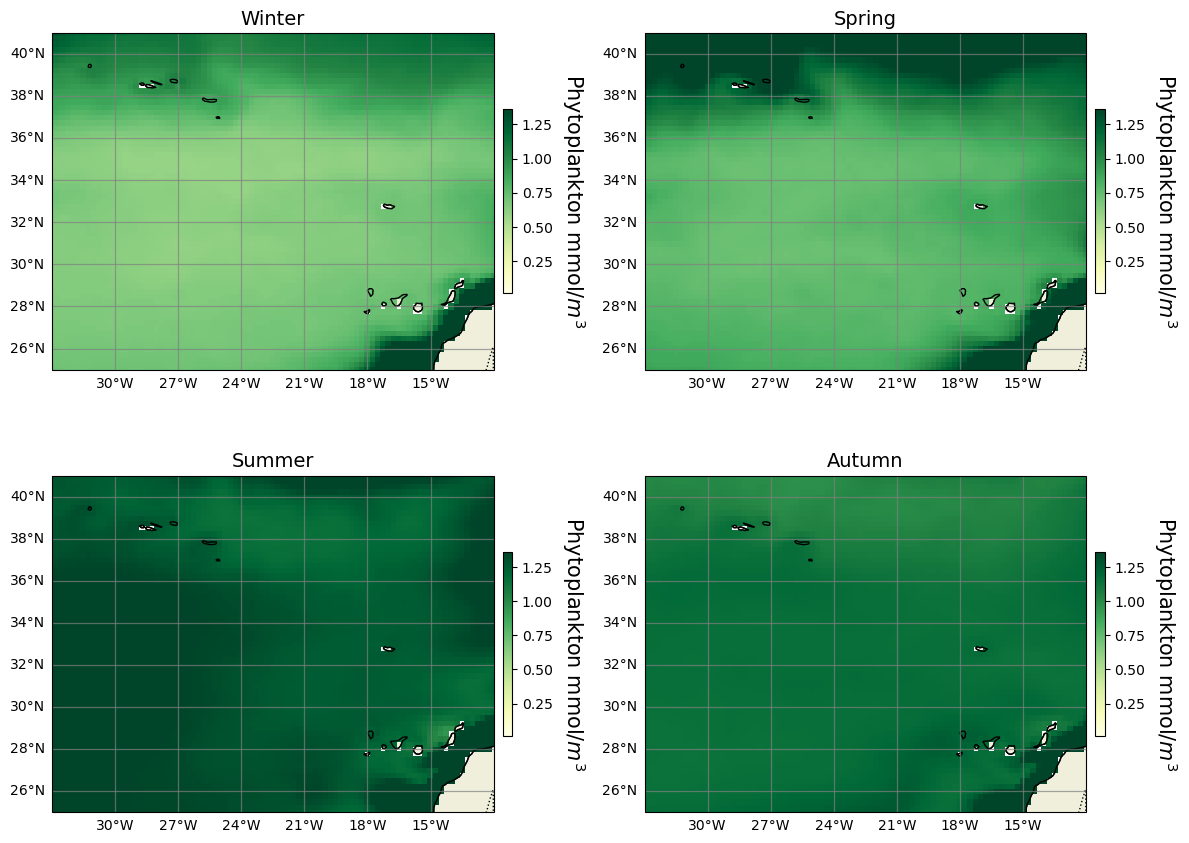

In [ ]:
f = plt.figure(figsize=(12,9))


seasons = ["DJF", "MAM", "JJA", "SON"]
# Dictionary seasons
seasons_name = {
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Autumn'
}
seasons = list(seasons_name.keys())

vmin = np.nanpercentile(ds_seas["phyc"].data, 2)  # 2th percentile
vmax = np.nanpercentile(ds_seas["phyc"].data, 98)  # 98th percentile

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')                            #'w', facecolor=
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.9, color='gray', alpha=0.7)
    gl.right_labels = False                                                            
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas.longitude.data, ds_seas.latitude.data, ds_seas['phyc'].sel(season=season).sel(depth=0, method="nearest").data, cmap='YlGn', vmin=vmin, vmax=vmax)  
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('Phytoplankton mmol/$m^3$', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f"{seasons_name[season]}", fontsize=14)    
    
#Uncomment to save figures 
   
#plt.savefig('fig/NewLTdatasetPercentilePhytoSeason1993_2025.pdf')
#plt.savefig('fig/NewLTdatasetPercentilePhytoSeason1993_2025.svg')
#plt.savefig('fig/NewLTdatasetPercentilePhytoSeason1993_2025.png')
plt.tight_layout()

In [39]:
# DIAGNOSTIC: Check if you're comparing apples to apples
print("CHLOROPHYLL (surface, season mean):")
for season in seasons:
    chl_val = ds_seas['chl'].sel(season=season).sel(depth=0, method="nearest").mean().values    
    print(f"{season}: {chl_val:.3f} mg/m³")

print("\nPHYTOPLANKTON CARBON (surface, season mean):")
for season in seasons:
    phyc_val = ds_seas['phyc'].sel(season=season).sel(depth=0, method="nearest").mean().values
    print(f"{season}: {phyc_val:.3f} mmol/m³")

# Check if phyc is really HIGHER in summer
summer_phyc = ds_seas['phyc'].sel(season='JJA').sel(depth=0, method="nearest").mean().values
spring_phyc = ds_seas['phyc'].sel(season='MAM').sel( depth=0, method="nearest").mean().values
print(f"\nPhyc Summer/Spring ratio: {summer_phyc/spring_phyc:.2f}")

CHLOROPHYLL (surface, season mean):
DJF: 0.103 mg/m³
MAM: 0.115 mg/m³
JJA: 0.098 mg/m³
SON: 0.080 mg/m³

PHYTOPLANKTON CARBON (surface, season mean):
DJF: 0.807 mmol/m³
MAM: 1.011 mmol/m³
JJA: 1.370 mmol/m³
SON: 1.173 mmol/m³

Phyc Summer/Spring ratio: 1.35


In [41]:
# Calculate Chl:C ratio (photoacclimation index)
for season in seasons:
    chl = ds_seas['chl'].sel(season=season).sel(depth=0, method="nearest")
    phyc = ds_seas['phyc'].sel(season=season).sel(depth=0, method="nearest")
    
    # Chl:C ratio (mg Chl / mmol C) - typical range: 0.01-0.1
    chl_c_ratio = (chl / phyc).mean().values
    
    print(f"{season}: Chl:C ratio = {chl_c_ratio:.4f} mg/mmol")
    print(f"  Mean Chl: {chl.mean().values:.3f} mg/m³")
    print(f"  Mean Phyc: {phyc.mean().values:.3f} mmol/m³")

DJF: Chl:C ratio = 0.1119 mg/mmol
  Mean Chl: 0.103 mg/m³
  Mean Phyc: 0.807 mmol/m³
MAM: Chl:C ratio = 0.1016 mg/mmol
  Mean Chl: 0.115 mg/m³
  Mean Phyc: 1.011 mmol/m³
JJA: Chl:C ratio = 0.0648 mg/mmol
  Mean Chl: 0.098 mg/m³
  Mean Phyc: 1.370 mmol/m³
SON: Chl:C ratio = 0.0644 mg/mmol
  Mean Chl: 0.080 mg/m³
  Mean Phyc: 1.173 mmol/m³


# 5. Long-term Variation
[Go back to the "Table of contents"](#Table-of-contents)

In [7]:
ds_avg = ds.groupby('time.year').mean().mean(dim=['latitude', 'longitude'])

In [12]:
ds_avg

<xarray.Dataset> Size: 20kB
Dimensions:  (year: 33, depth: 75)
Coordinates:
  * depth    (depth) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * year     (year) int64 264B 1993 1994 1995 1996 1997 ... 2022 2023 2024 2025
Data variables:
    chl      (year, depth) float32 10kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    phyc     (year, depth) float32 10kB dask.array<chunksize=(1, 50), meta=np.ndarray>

In [8]:
ds_avg_surface = ds_avg.sel(depth = 0, method='nearest')

In [14]:
ds_avg_surface

<xarray.Dataset> Size: 532B
Dimensions:  (year: 33)
Coordinates:
    depth    float32 4B 0.5058
  * year     (year) int64 264B 1993 1994 1995 1996 1997 ... 2022 2023 2024 2025
Data variables:
    chl      (year) float32 132B dask.array<chunksize=(1,), meta=np.ndarray>
    phyc     (year) float32 132B dask.array<chunksize=(1,), meta=np.ndarray>

In [9]:
ds_avg_surface_chl = ds_avg_surface['chl']
ds_avg_surface_phyt = ds_avg_surface['phyc']

In [10]:
slope_chl, intercept_chl, r_chl, p_chl, se_chl = linregress(ds_avg_surface_chl.year.data,  ds_avg_surface_chl.data)
trend_vals_chl = ds_avg_surface_chl.year.data*slope_chl + intercept_chl

In [17]:
print(f'slope chl = {slope_chl}')
print(f'intercept chl = {intercept_chl}')
print(f'r chl = {r_chl}')
print(f'p chl = {p_chl}')
print(f'standard error chl = {se_chl}')

slope chl = 0.0004034494547880587
intercept chl = -0.7113082929823127
r chl = 0.37546373623914464
p chl = 0.03130407328673614
standard error chl = 0.00017887254710601298


In [11]:
slope_phyto, intercept_phyto, r_phyto, p_phyto, se_phyto = linregress(ds_avg_surface_phyt.year.data,  ds_avg_surface_phyt.data)
trend_vals_phyto = ds_avg_surface_phyt.year.data*slope_phyto + intercept_phyto

In [19]:
print(f'slope phyto = {slope_phyto}')
print(f'intercept phyto = {intercept_phyto}')
print(f'r phyto = {r_phyto}')
print(f'p phyto = {p_phyto}')
print(f'standard error phyto = {se_phyto}')

slope phyto = 0.0022054278356506223
intercept phyto = -3.339586662935382
r phyto = 0.5892489380947983
p phyto = 0.0003085522484737535
standard error phyto = 0.0005431233927886859


**Chlorophyll *a***

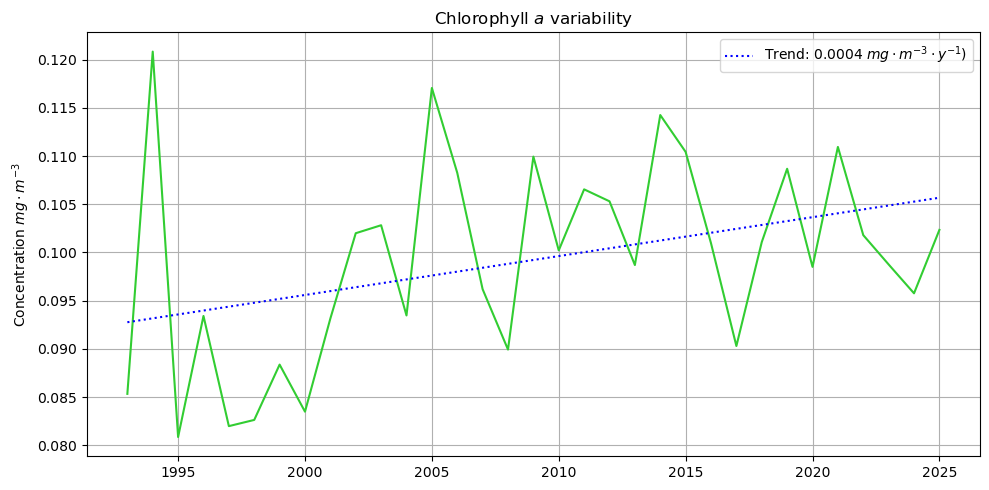

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_avg_surface_chl.year.data, ds_avg_surface_chl.data, color='limegreen')
ax.plot(ds_avg_surface_chl.year.data, trend_vals_chl, color='b', linestyle=':', label=f"Trend: {slope_chl:.4f} $mg \cdot m^{{-3}} \cdot y^{{-1}}$)") #'%.4f $mg \cdot m^{-3} \cdot y^{-1}$' % slopeChl)
ax.set_title(r'Chlorophyll $\it{a}$ variability')    #\nCorrelation Coef : r= %.2f' %rChl
ax.set_ylabel('Concentration $mg \cdot m^{-3}$')
ax.grid(True)
ax.legend()

plt.tight_layout()
#fig.savefig('HindcastChlaRegrLineNoYearLTsize10-5.svg')
#fig.savefig('HindcastChlaRegrLineNoYearLTsize10-5.pdf')
#fig.savefig('HindcastChlaRegrLineNoYearLTsize10-5.png')

**Phytoplankton**

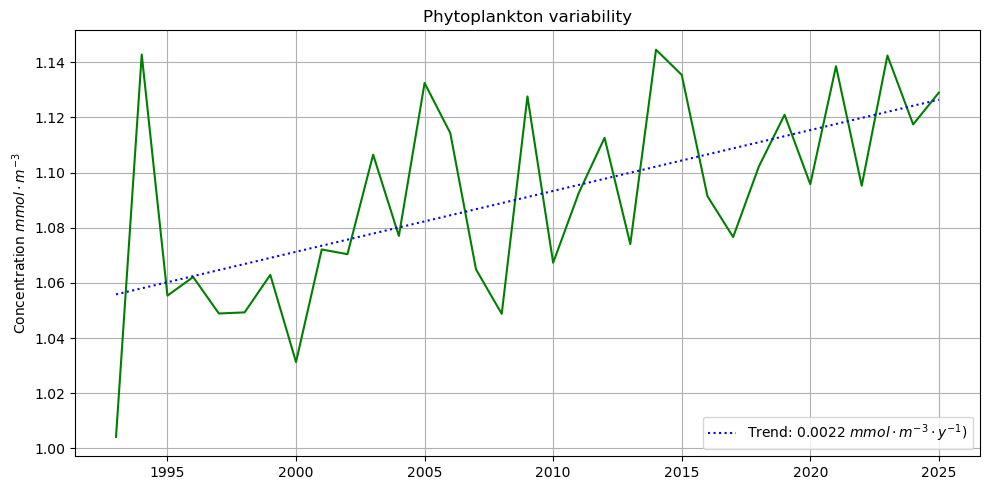

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_avg_surface_phyt.year.data, ds_avg_surface_phyt.data, color='green')
ax.plot(ds_avg_surface_phyt.year.data, trend_vals_phyto, color='b', linestyle=':', label=f"Trend: {slope_phyto:.4f} $mmol \cdot m^{{-3}} \cdot y^{{-1}}$)") #'%.4f $mg \cdot m^{-3} \cdot y^{-1}$' % slopeChl)
ax.set_title('Phytoplankton variability')    #\nCorrelation Coef : r= %.2f' %rChl
ax.set_ylabel('Concentration $mmol \cdot m^{-3}$')
ax.grid(True)
ax.legend()
plt.tight_layout()
#plt.savefig('HindcastPhytoRegrLineSize10-5.svg')
#plt.savefig('HindcastPhytoRegrLineSize10-5.pdf')
#plt.savefig('HindcastPhytoRegrLineSize10-5.png')

# 6. Vertical Variation
[Go back to the "Table of contents"](#Table-of-contents)

In [ ]:
# Mean on geographic area
chl_area = ds["chl"].mean(dim=["latitude", "longitude"])

In [ ]:
#Mean on seasons
chl_seas = chl_area.groupby("time.season").mean()

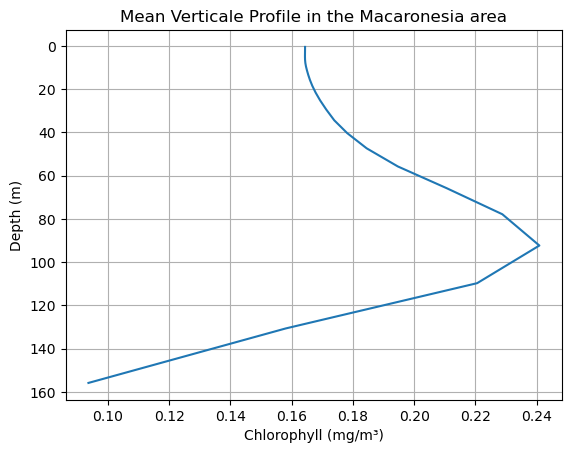

In [ ]:
# Mean in time
chl_profile = chl_area.mean(dim="time")

# Grafico
plt.plot(chl_profile, chl_profile["depth"])
plt.gca().invert_yaxis()
plt.title("Mean Verticale Profile in the Macaronesia area")
plt.xlabel("Chlorophyll (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.savefig('MeanVerticaleProfileMacaronesia.png')
plt.show()


In [ ]:

depths = chl_seas["depth"]


seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]


season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

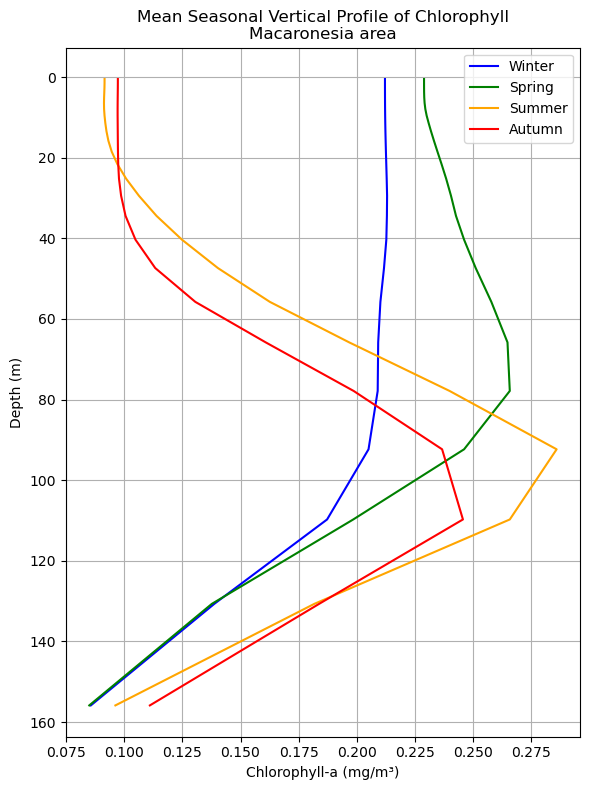

In [ ]:


# plot
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    plt.plot(chl_seas.sel(season=season), depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Chlorophyll\nMacaronesia area")
plt.xlabel("Chlorophyll-a (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("MeanSeasonalVerticalProfile_Macaronesia.png")
plt.show()


**Select geographic area  of interest**

**Azores**

In [ ]:
chl_areaAzores = ds["chl"].sel(latitude=slice(lat_minAzores, lat_maxAzores), longitude=slice(lon_minAzores, lon_maxAzores))

In [ ]:
chl_seas_Azores = chl_areaAzores.groupby("time.season").mean()

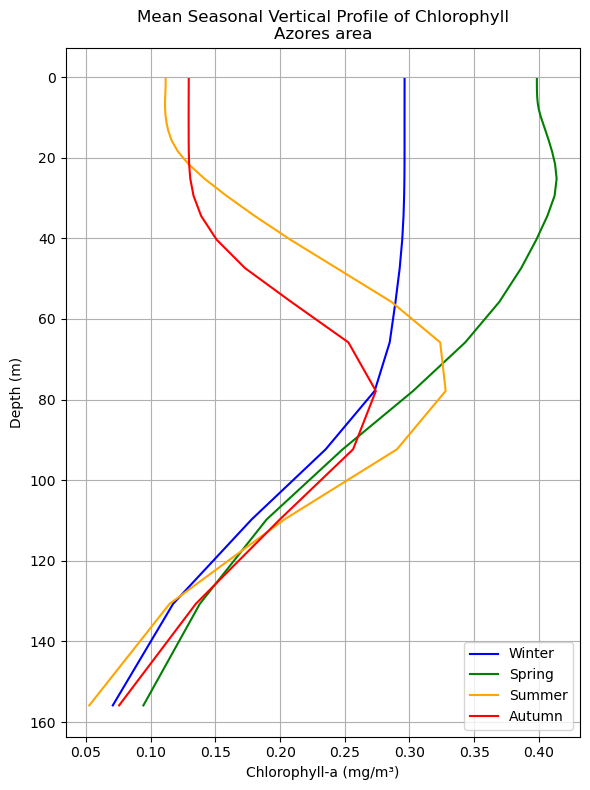

In [ ]:
# plot
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    # ⬇️ importante: seleziona la variabile 'chl'
    chl_vals = chl_seas_Azores.sel(season=season)
    plt.plot(chl_vals, depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Chlorophyll\nAzores area")
plt.xlabel("Chlorophyll-a (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("MeanSeasonalVerticalProfile_Azores.png")
plt.show()


**Canary Islands**

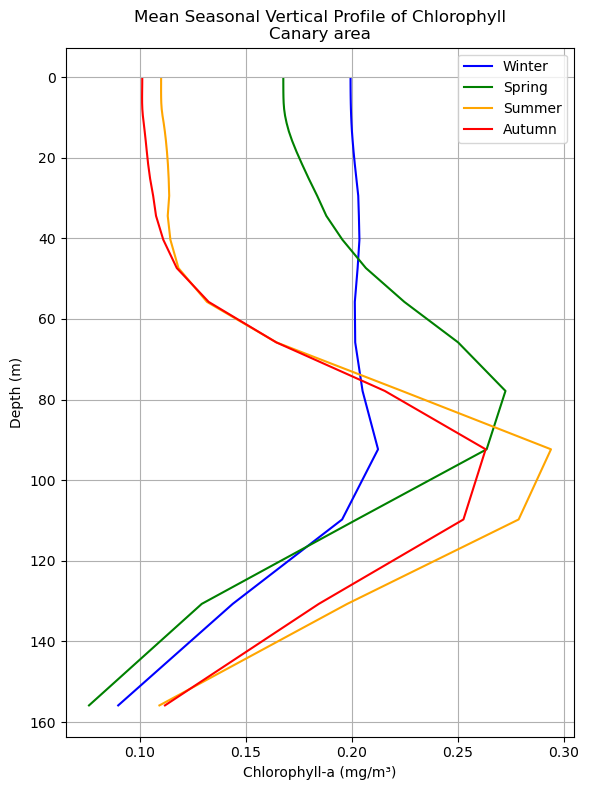

In [ ]:
#Slice the area
chl_areaCanary = ds["chl"].sel(latitude=slice(lat_minCanary, lat_maxCanary), longitude=slice(lon_minCanary, lon_maxCanary))

# Spatial Mean canary
chl_areaCanaryMean = chl_areaCanary.mean(dim=["latitude", "longitude"])

# Seasonal mean
chl_seas_Canary = chl_areaCanaryMean.groupby("time.season").mean()



# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    # ⬇️ importante: seleziona la variabile 'chl'
    chl_vals = chl_seas_Canary.sel(season=season)
    plt.plot(chl_vals, depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Chlorophyll\nCanary area")
plt.xlabel("Chlorophyll-a (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("MeanSeasonalVerticalProfile_Canary.png")
plt.show()


**Madeira**

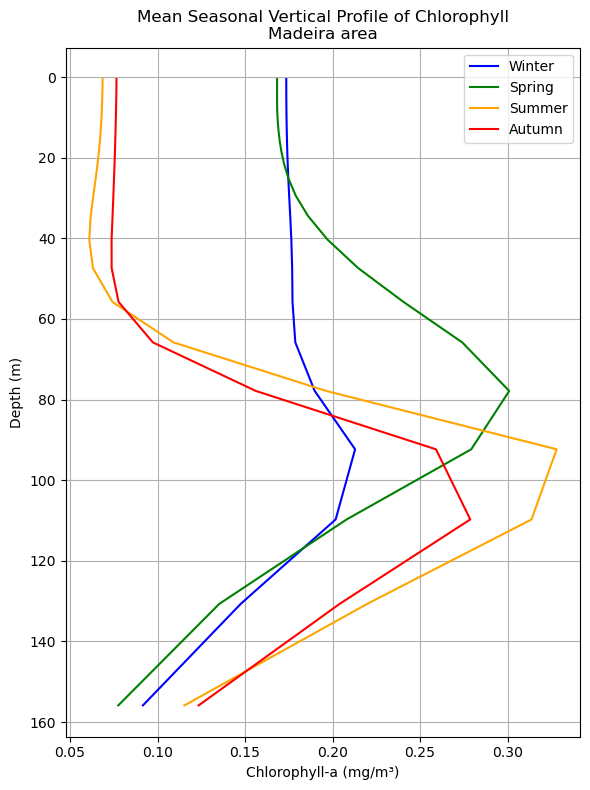

In [ ]:
chl_areaMadeira = ds["chl"].sel(
    latitude=slice(lat_minMadeira, lat_maxMadeira), longitude=slice(lon_minMadeira, lon_maxMadeira)
    ).mean(dim=["latitude", "longitude"])



# Media stagionale per profondità
chl_seas_Madeira = chl_areaMadeira.groupby("time.season").mean()


# Profondità
depths_Madeira = chl_seas_Madeira["depth"]

# Lista stagioni ordinate
seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]

#Dizionario per le stagioni
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    chl_vals = chl_seas_Madeira.sel(season=season)
    plt.plot(chl_vals, depths_Madeira, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Chlorophyll\nMadeira area")
plt.xlabel("Chlorophyll-a (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("MeanSeasonalVerticalProfile_Madeira.png")
plt.show()


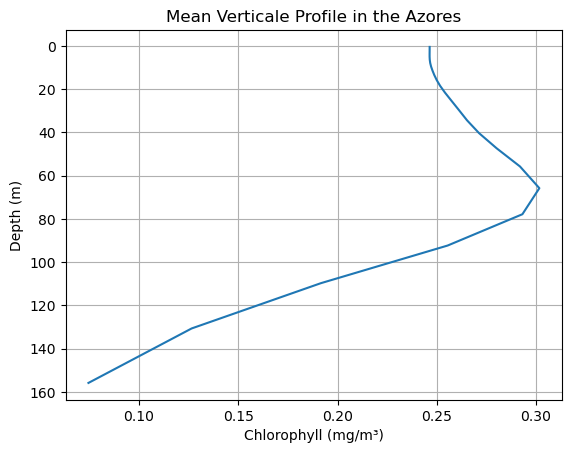

In [ ]:
# Media su tutti i time step
chl_profileAzores = chl_areaAzores.mean(dim=["latitude", "longitude"]).mean(dim="time")

# Grafico
plt.plot(chl_profileAzores, chl_profileAzores["depth"])
plt.gca().invert_yaxis()
plt.title("Mean Verticale Profile in the Azores")
plt.xlabel("Chlorophyll (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.savefig('MeanVerticaleProfileAzores.png')
plt.show()

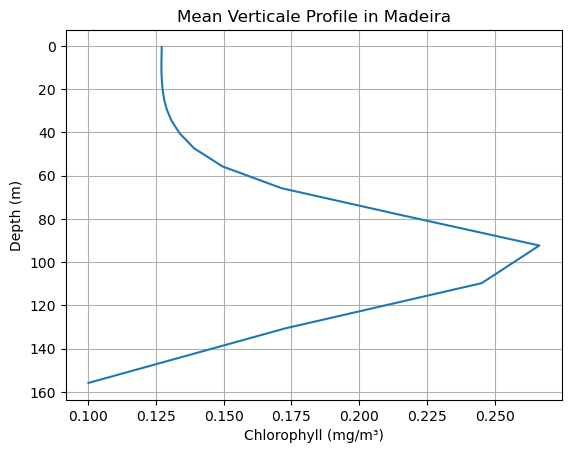

In [117]:
# Media su tutti i time step
chl_profileMadeira = chl_areaMadeira.mean(dim=["latitude", "longitude"]).mean(dim="time")

# Grafico
plt.plot(chl_profileMadeira, chl_profileMadeira["depth"])
plt.gca().invert_yaxis()
plt.title("Mean Verticale Profile in Madeira")
plt.xlabel("Chlorophyll (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.savefig('MeanVerticaleProfileMadeira.png')
plt.show()

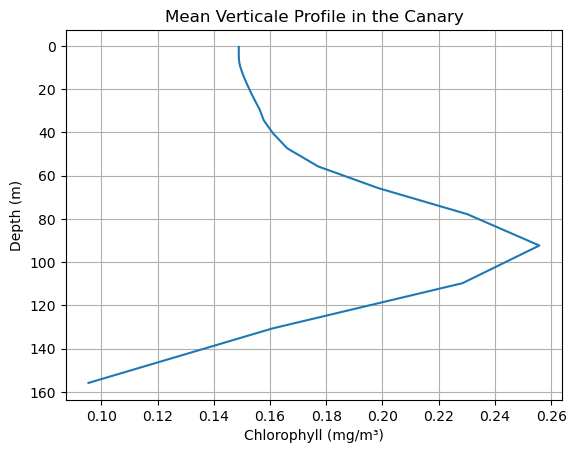

In [118]:
# Media su tutti i time step
chl_profileCanary = chl_areaCanary.mean(dim=["latitude", "longitude"]).mean(dim="time")

# Grafico
plt.plot(chl_profileCanary, chl_profileCanary["depth"])
plt.gca().invert_yaxis()
plt.title("Mean Verticale Profile in the Canary")
plt.xlabel("Chlorophyll (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.savefig('MeanVerticaleProfileCanary.png')
plt.show()

In [ ]:
ds_chl_seas = ds_seas['chl']

**Phytoplankton**

In [16]:
ds_phyc_seas =  ds_seas['phyc']
ds_phyc_seas

<xarray.DataArray 'phyc' (season: 4, depth: 25, latitude: 69, longitude: 93)> Size: 3MB
array([[[[0.80954176, 0.82090753, 0.8127721 , ...,        nan,
                 nan,        nan],
         [0.81160724, 0.8299179 , 0.81620085, ...,        nan,
                 nan,        nan],
         [0.817615  , 0.8243037 , 0.8135319 , ...,        nan,
                 nan,        nan],
         ...,
         [1.2315708 , 1.2370183 , 1.2233437 , ..., 1.3885819 ,
          1.3962519 , 1.406192  ],
         [1.2364103 , 1.2300725 , 1.2116253 , ..., 1.3864762 ,
          1.3986205 , 1.4122794 ],
         [1.2232118 , 1.2219489 , 1.2127945 , ..., 1.3864639 ,
          1.3925169 , 1.4031056 ]],

        [[0.80950385, 0.8208731 , 0.8127359 , ...,        nan,
                 nan,        nan],
         [0.811571  , 0.82988334, 0.8161655 , ...,        nan,
                 nan,        nan],
         [0.8175814 , 0.8242709 , 0.81349987, ...,        nan,
                 nan,        nan],
...
         [0.2571076 , 0.25303024, 0.25126606, ..., 0.22912072,
          0.22730738, 0.23343378],
         [0.24707407, 0.24560116, 0.24799211, ..., 0.21694268,
          0.21903244, 0.22377361],
         [0.240353  , 0.24198556, 0.24845025, ..., 0.21189044,
          0.21749258, 0.2231058 ]],

        [[0.48746076, 0.48705822, 0.48055094, ...,        nan,
                 nan,        nan],
         [0.48688716, 0.49007866, 0.48338962, ...,        nan,
                 nan,        nan],
         [0.48381472, 0.48442763, 0.48539433, ...,        nan,
                 nan,        nan],
         ...,
         [0.1604342 , 0.1580418 , 0.15641113, ..., 0.12095883,
          0.11985113, 0.1258127 ],
         [0.15417463, 0.1526437 , 0.15443166, ..., 0.113812  ,
          0.11452592, 0.11876166],
         [0.14874686, 0.1492294 , 0.15254791, ..., 0.10785668,
          0.11071372, 0.11568299]]]], dtype=float32)
Coordinates:
  * depth      (depth) float32 100B 0.494 1.541 2.646 ... 109.7 130.7 155.9
  * latitude   (latitude) float32 276B 25.0 25.25 25.5 25.75 ... 41.5 41.75 42.0
  * longitude  (longitude) float32 372B -34.0 -33.75 -33.5 ... -11.25 -11.0
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    long_name:      Total Phytoplankton
    standard_name:  mole_concentration_of_phytoplankton_expressed_as_carbon_i...
    unit_long:      millimoles per cubic meter
    units:          mmol m-3
    valid_max:      150.0
    valid_min:      0.0

# Phytoplankton

In [ ]:
phyto_area = ds["phyc"].mean(dim=["latitude", "longitude"])

In [260]:
phyc_seas = phyto_area.groupby("time.season").mean()

**Plot of the phytoplankton in the entire area**

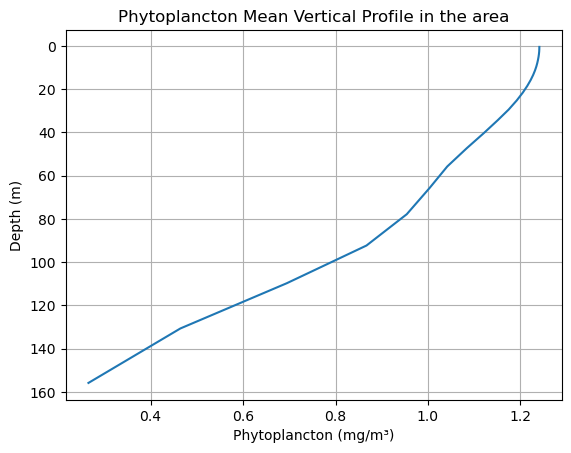

In [ ]:


# Media su tutti i time step
phyto_profile = phyto_area.mean(dim="time")

# Grafico
plt.plot(phyto_profile, phyto_profile["depth"])
plt.gca().invert_yaxis()
plt.title("Phytoplancton Mean Vertical Profile in the area")
plt.xlabel("Phytoplancton (mg/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.show()


**Plot of the phytoplankton in the entire area by season**

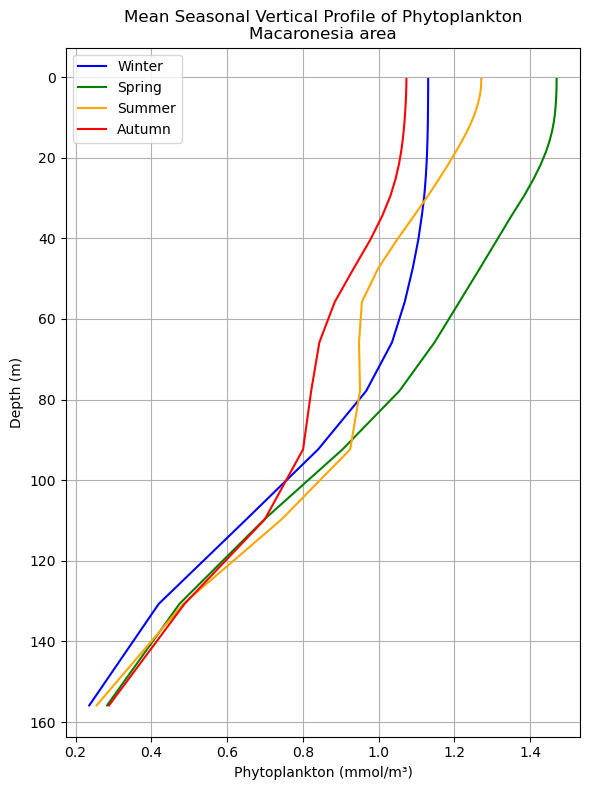

In [266]:
# Profondità
depths = chl_seas["depth"]

# Lista stagioni ordinate
seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]

#Dizionario per le stagioni
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    plt.plot(phyc_seas.sel(season=season), depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Phytoplankton\nMacaronesia area")
plt.xlabel("Phytoplankton (mmol/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("PhytoMeanSeasonalVerticalProfile_Macaronesia.png")
plt.show()


**Plot of the phytoplankton in the Azores**

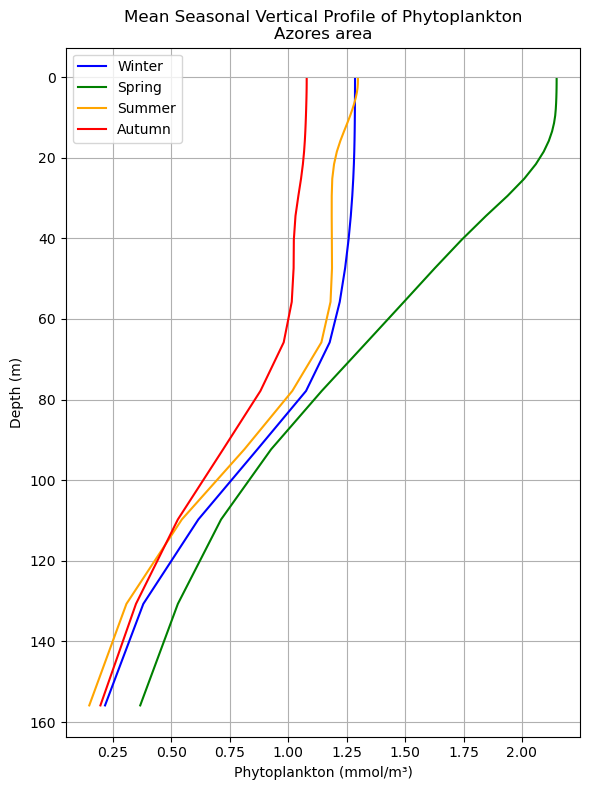

In [267]:
# Media spaziale nella regione delle Azzorre
phyc_areaAzores = ds["phyc"].sel(
    latitude=slice(lat_minAzores, lat_maxAzores),
    longitude=slice(lon_minAzores, lon_maxAzores)
).mean(dim=["latitude", "longitude"])

# Media stagionale per profondità
phyc_seas_Azores = phyc_areaAzores.groupby("time.season").mean()

# Profondità
#depths_Azores = chl_seas_Azores["depth"]

# Stagioni ordinate + colori
seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]

# Dizionario per nomi leggibili
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    # ⬇️ importante: seleziona la variabile 'chl'
    phyc_vals = phyc_seas_Azores.sel(season=season)
    plt.plot(phyc_vals, depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Phytoplankton\nAzores area")
plt.xlabel("Phytoplankton (mmol/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("PhytoMeanSeasonalVerticalProfile_Azores.png")
plt.show()


**Plot of the phytoplankton in Madeira**

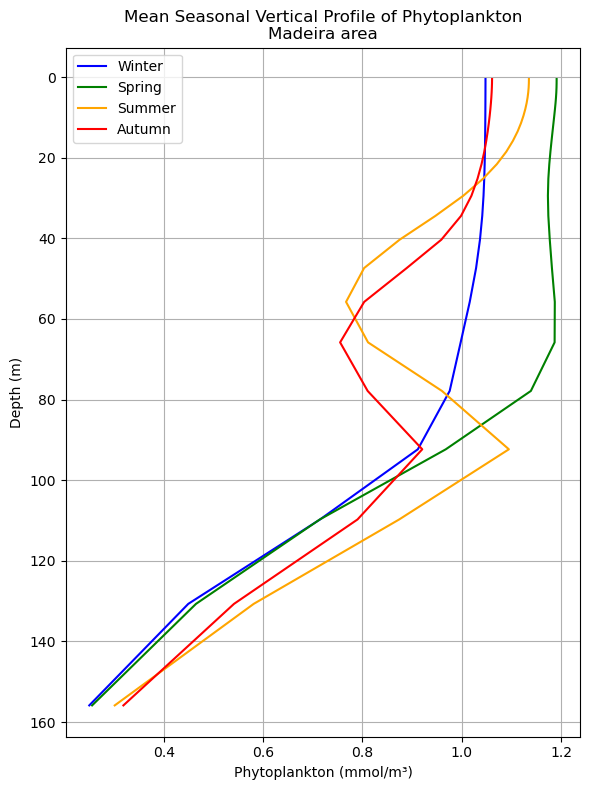

In [269]:
# Media spaziale nella regione delle Madeira
phyc_areaMadeira = ds["phyc"].sel(
    latitude=slice(lat_minMadeira, lat_maxMadeira),
    longitude=slice(lon_minMadeira, lon_maxMadeira)
).mean(dim=["latitude", "longitude"])

# Media stagionale per profondità
phyc_seas_Madeira = phyc_areaMadeira.groupby("time.season").mean()

# Profondità
#depths_Azores = chl_seas_Azores["depth"]

# Stagioni ordinate + colori
seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]

# Dizionario per nomi leggibili
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    # ⬇️ importante: seleziona la variabile 'chl'
    phyc_vals = phyc_seas_Madeira.sel(season=season)
    plt.plot(phyc_vals, depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Phytoplankton\nMadeira area")
plt.xlabel("Phytoplankton (mmol/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("PhytoMeanSeasonalVerticalProfile_Madeira.png")
plt.show()


**Plot of the phytoplankton in Canary Islands**

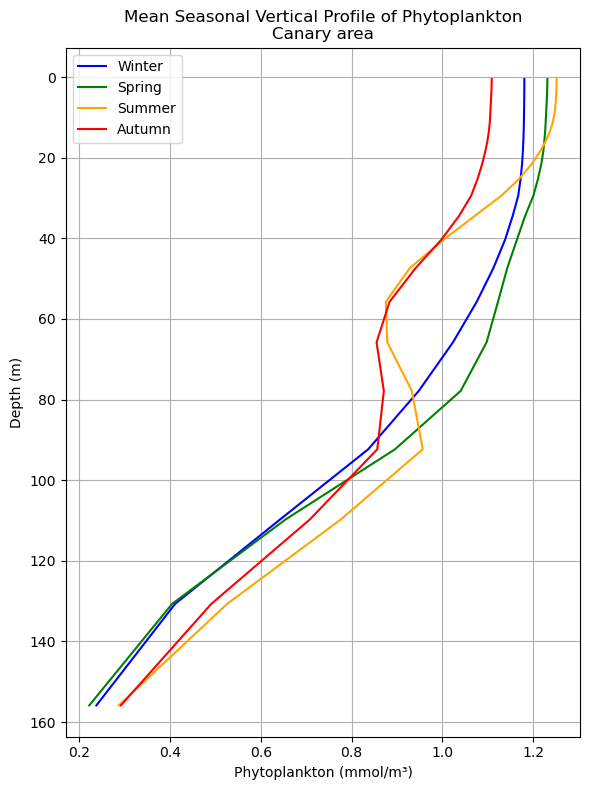

In [270]:
# Media spaziale nella regione delle Azzorre
phyc_areaCanary = ds["phyc"].sel(
    latitude=slice(lat_minCanary, lat_maxCanary),
    longitude=slice(lon_minCanary, lon_maxCanary)
).mean(dim=["latitude", "longitude"])

# Media stagionale per profondità
phyc_seas_Canary = phyc_areaCanary.groupby("time.season").mean()

# Profondità
#depths_Azores = chl_seas_Azores["depth"]

# Stagioni ordinate + colori
seasons = ["DJF", "MAM", "JJA", "SON"]
colors = ["blue", "green", "orange", "red"]

# Dizionario per nomi leggibili
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

# Grafico
plt.figure(figsize=(6, 8))

for season, color in zip(seasons, colors):
    # ⬇️ importante: seleziona la variabile 'chl'
    phyc_vals = phyc_seas_Canary.sel(season=season)
    plt.plot(phyc_vals, depths, label=season_names[season], color=color)

plt.gca().invert_yaxis()
plt.title("Mean Seasonal Vertical Profile of Phytoplankton\nCanary area")
plt.xlabel("Phytoplankton (mmol/m³)")
plt.ylabel("Depth (m)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("PhytoMeanSeasonalVerticalProfile_Canary.png")
plt.show()


# 7. Correlations between chlorophyll and phytoplankton

[Go back to the "Table of contents"](#Table-of-contents)


Xarray allows you to correlate variables from a dataset along chosen dimensions. Let's correlate SST and current velocity to see if the result supports the upwelling phenomenon observed in the Guld of Guinea.



In [224]:
# correlation between sst and ocean currents

correlation = xr.corr(ds_chl_seas, ds_phyc_seas, dim='season')
correlation

<xarray.DataArray (depth: 25, latitude: 69, longitude: 93)> Size: 642kB
array([[[-0.8029637 , -0.8227754 , -0.8161921 , ...,         nan,
                 nan,         nan],
        [-0.8048244 , -0.818107  , -0.8205714 , ...,         nan,
                 nan,         nan],
        [-0.79638475, -0.7885089 , -0.8162116 , ...,         nan,
                 nan,         nan],
        ...,
        [ 0.93085074,  0.9336827 ,  0.93750143, ...,  0.6609177 ,
          0.6678616 ,  0.6657667 ],
        [ 0.92953116,  0.9330688 ,  0.9375048 , ...,  0.6106531 ,
          0.65206665,  0.6837167 ],
        [ 0.92978764,  0.9310167 ,  0.9342519 , ...,  0.6062195 ,
          0.650226  ,  0.6726937 ]],

       [[-0.8029464 , -0.82275635, -0.8162178 , ...,         nan,
                 nan,         nan],
        [-0.8047595 , -0.8180606 , -0.8205787 , ...,         nan,
                 nan,         nan],
        [-0.7963115 , -0.7884495 , -0.81616884, ...,         nan,
                 nan,         nan],
...
        [ 0.9915129 ,  0.9923489 ,  0.991771  , ...,  0.65754384,
          0.69900584,  0.83867186],
        [ 0.99029404,  0.99160916,  0.9904374 , ...,  0.6361696 ,
          0.7679648 ,  0.86742496],
        [ 0.9888211 ,  0.98963034,  0.98908246, ...,  0.63239145,
          0.76272887,  0.819998  ]],

       [[ 0.73504114,  0.8299143 ,  0.8778351 , ...,         nan,
                 nan,         nan],
        [ 0.7459814 ,  0.858885  ,  0.86278385, ...,         nan,
                 nan,         nan],
        [ 0.88505703,  0.9348689 ,  0.94034696, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.991457  ,  0.99289566,  0.99305636, ...,  0.90853506,
          0.94444484,  0.97837937],
        [ 0.9910031 ,  0.9929185 ,  0.9930733 , ...,  0.9067202 ,
          0.95045114,  0.9705943 ],
        [ 0.98981875,  0.9907924 ,  0.9902767 , ...,  0.91879094,
          0.94997936,  0.94636273]]], dtype=float32)
Coordinates:
  * depth      (depth) float32 100B 0.494 1.541 2.646 ... 109.7 130.7 155.9
  * latitude   (latitude) float32 276B 25.0 25.25 25.5 25.75 ... 41.5 41.75 42.0
  * longitude  (longitude) float32 372B -34.0 -33.75 -33.5 ... -11.25 -11.0

We have computed correlation along the *time* coordinate. Therefore our result is a correlation map : with a correlation coefficient between chlorophyll *a* and phytoplankton for each pixel. Let's visualize this by depth.

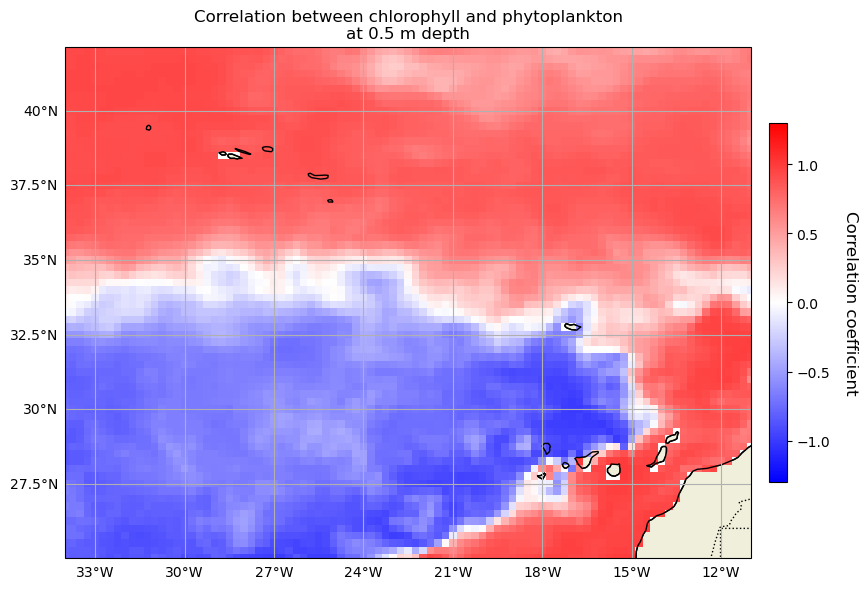

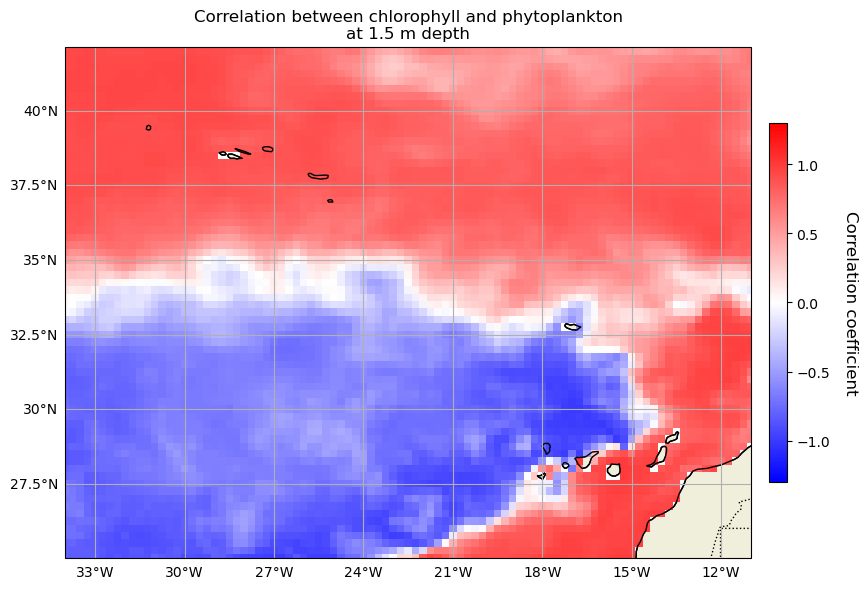

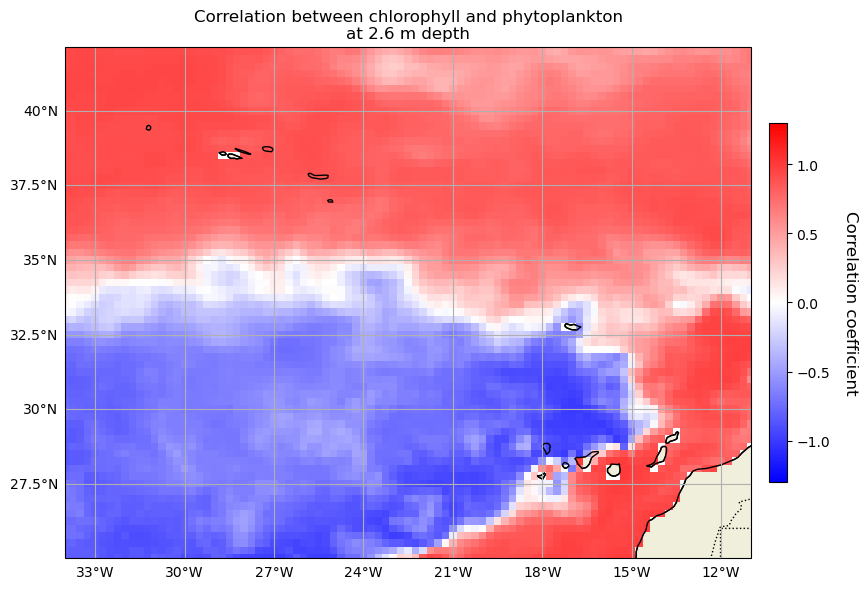

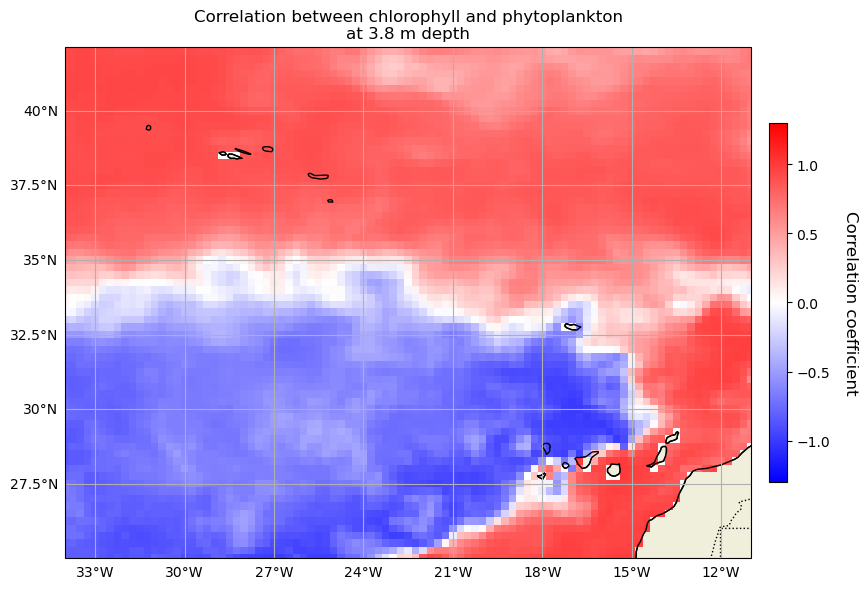

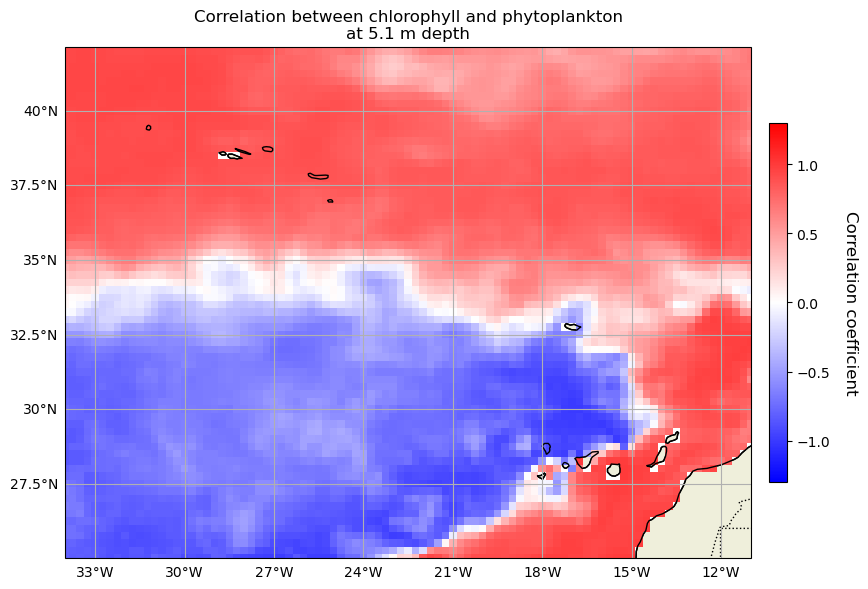

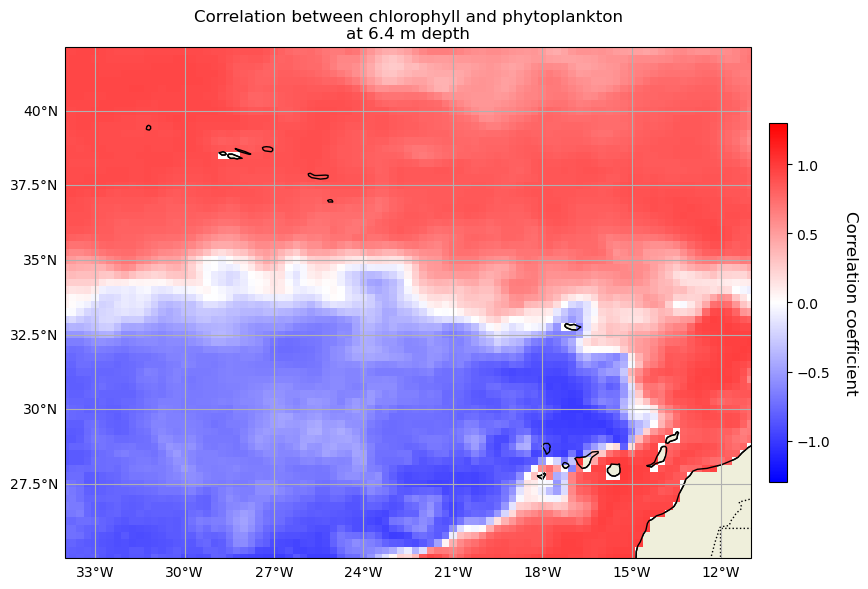

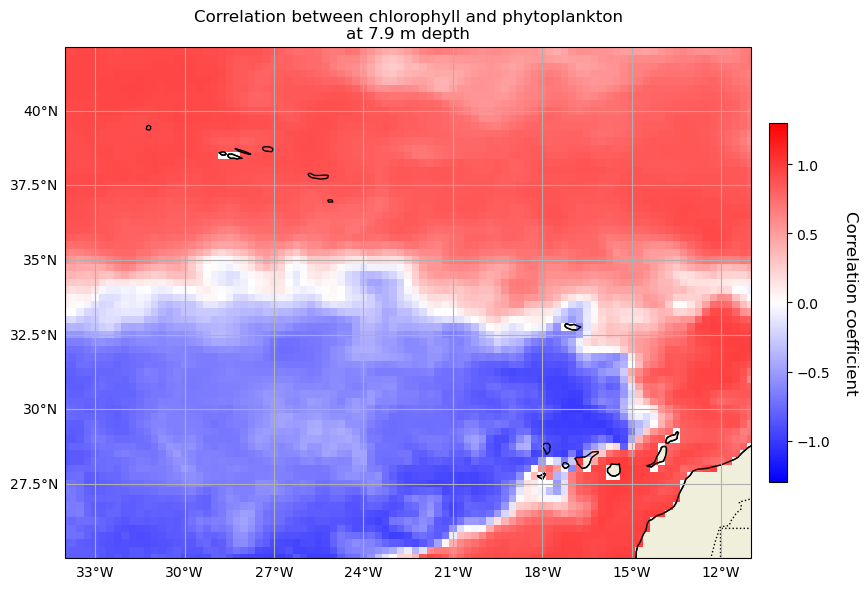

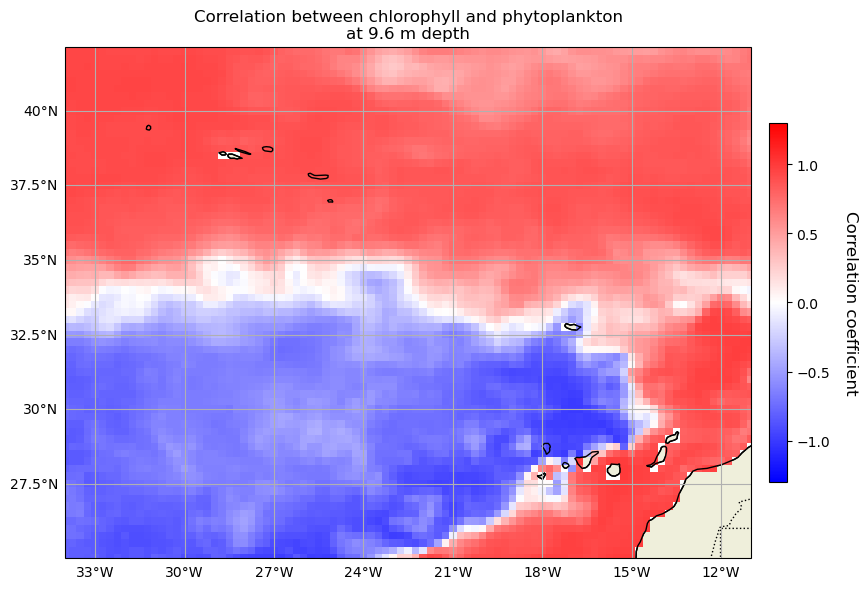

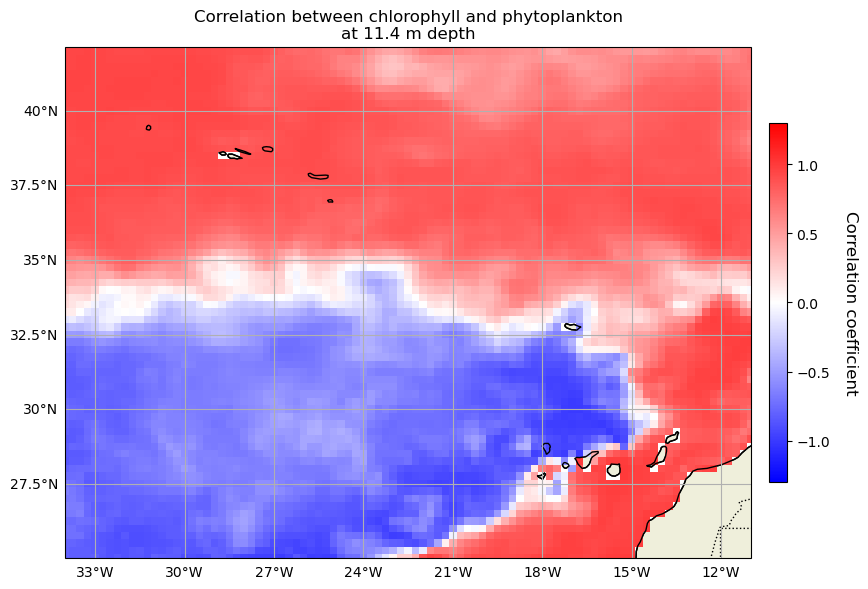

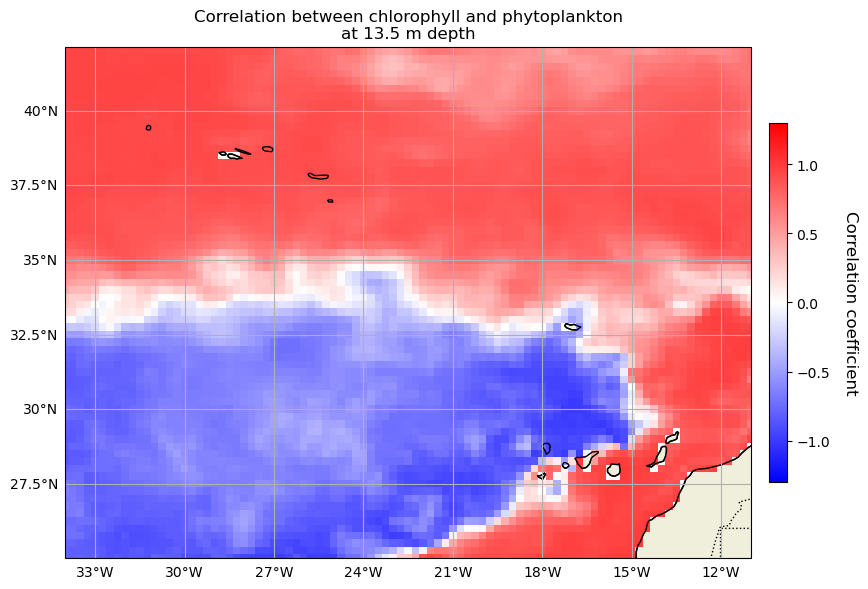

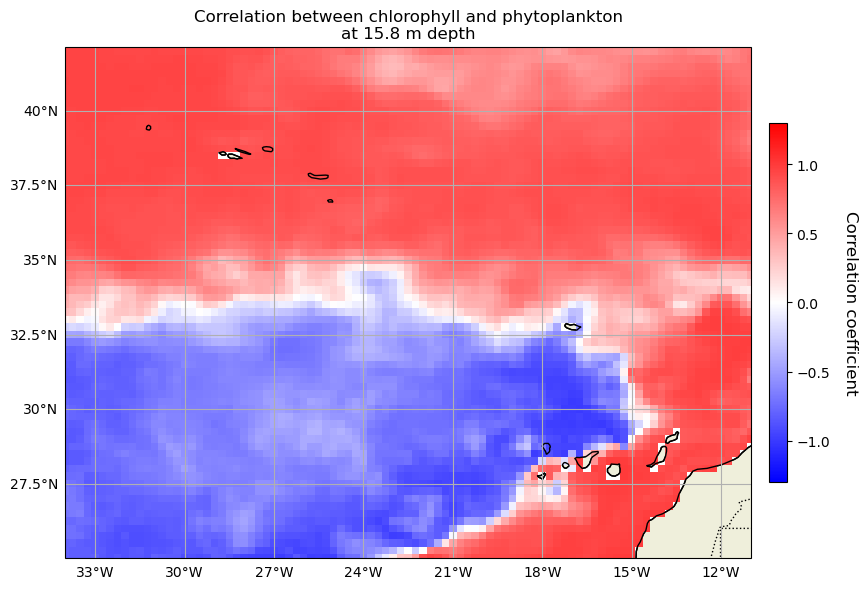

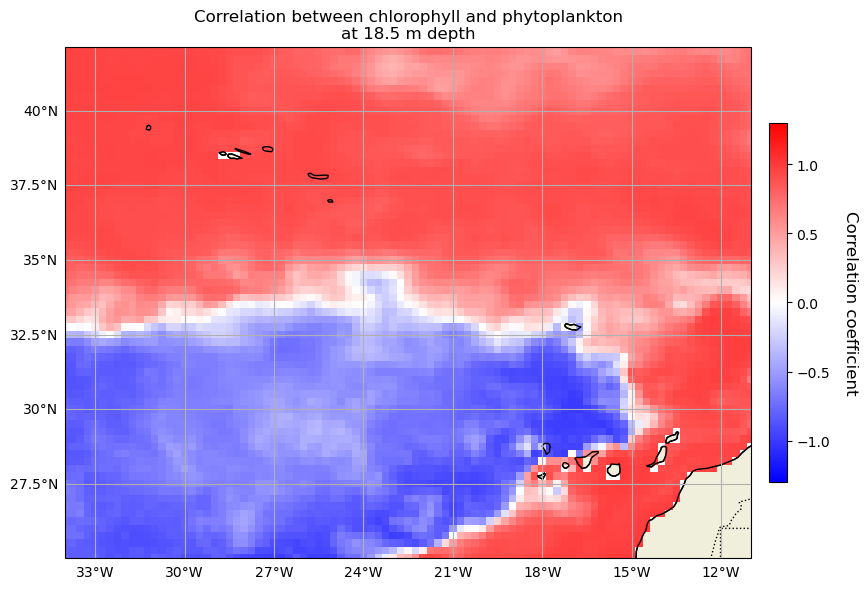

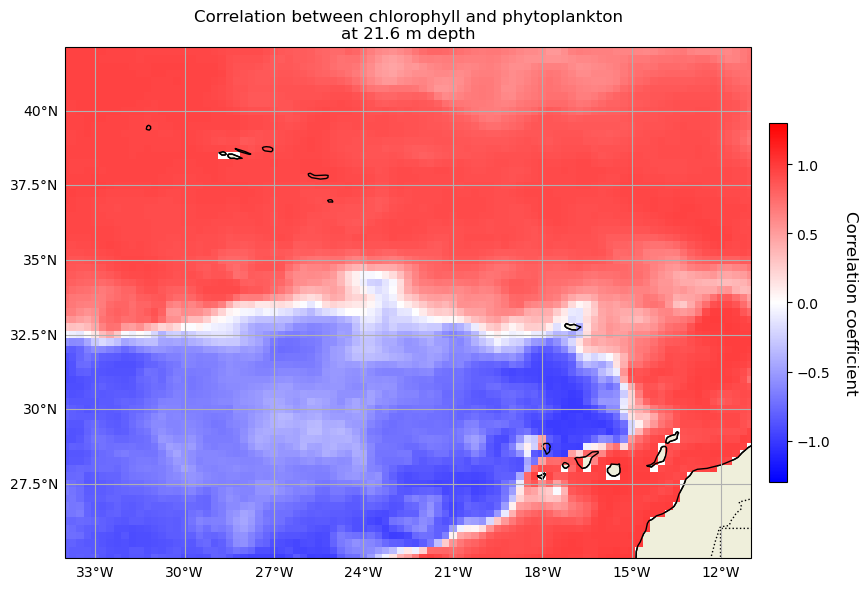

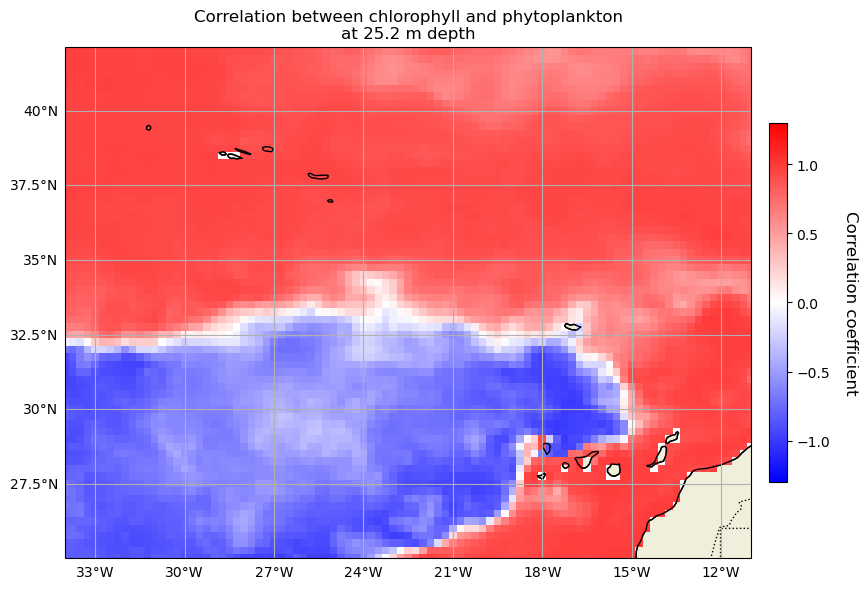

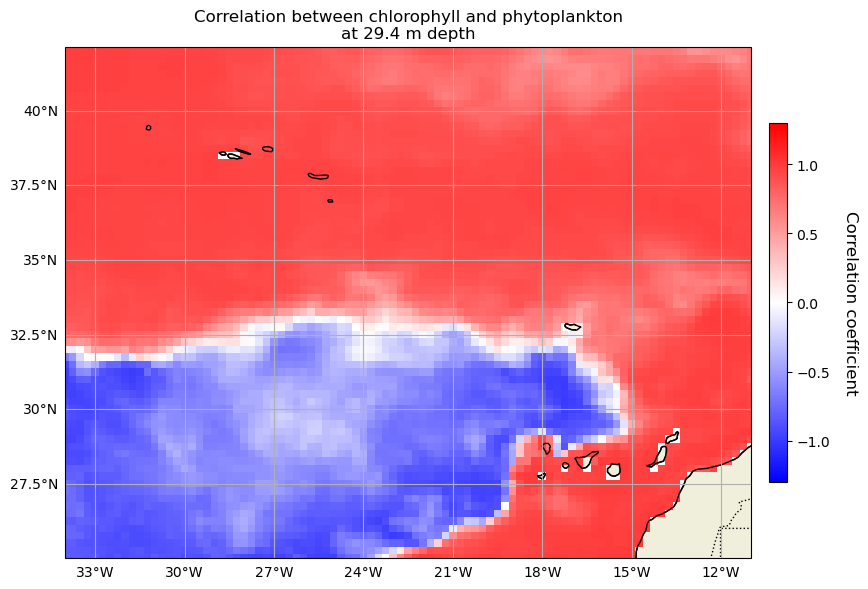

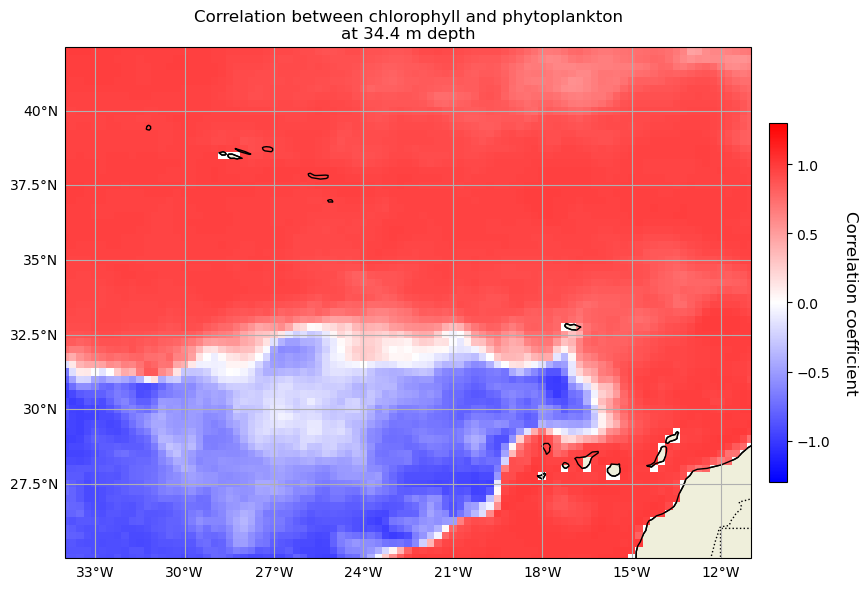

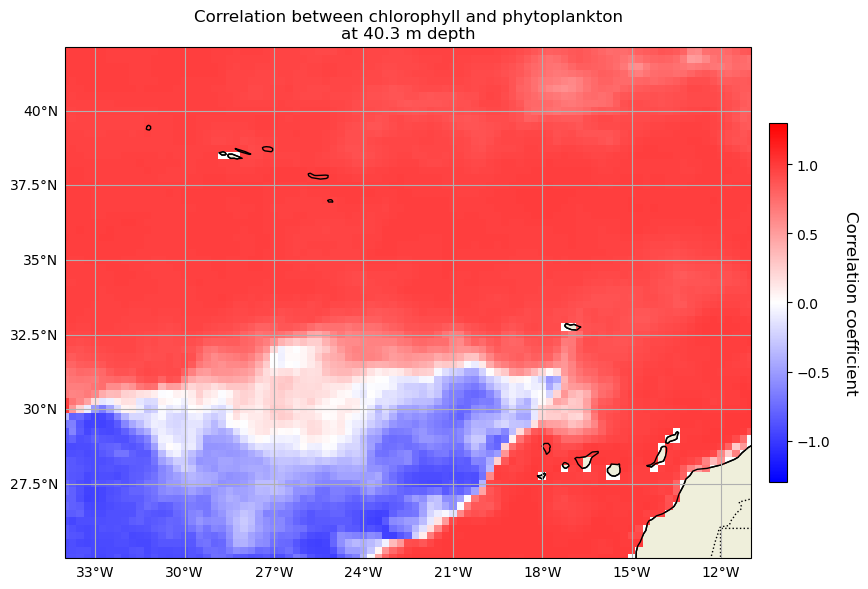

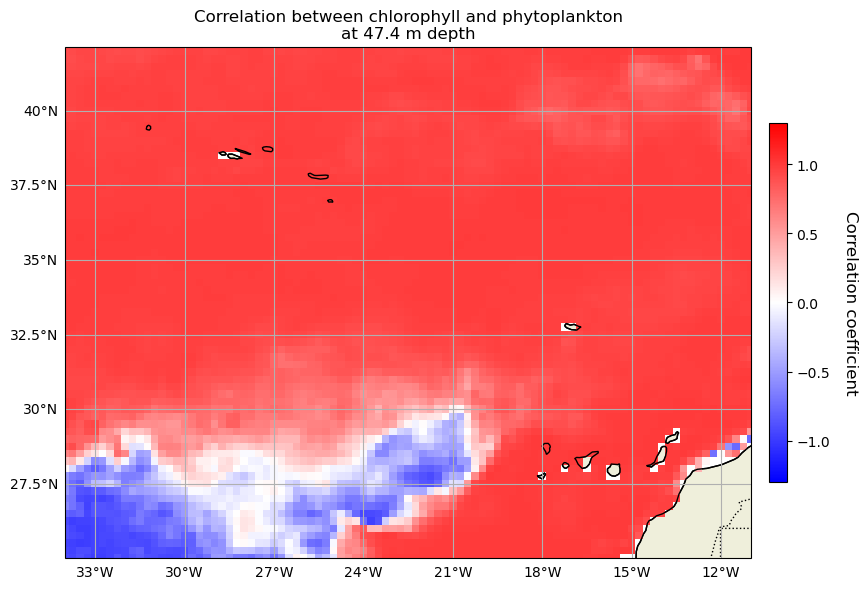

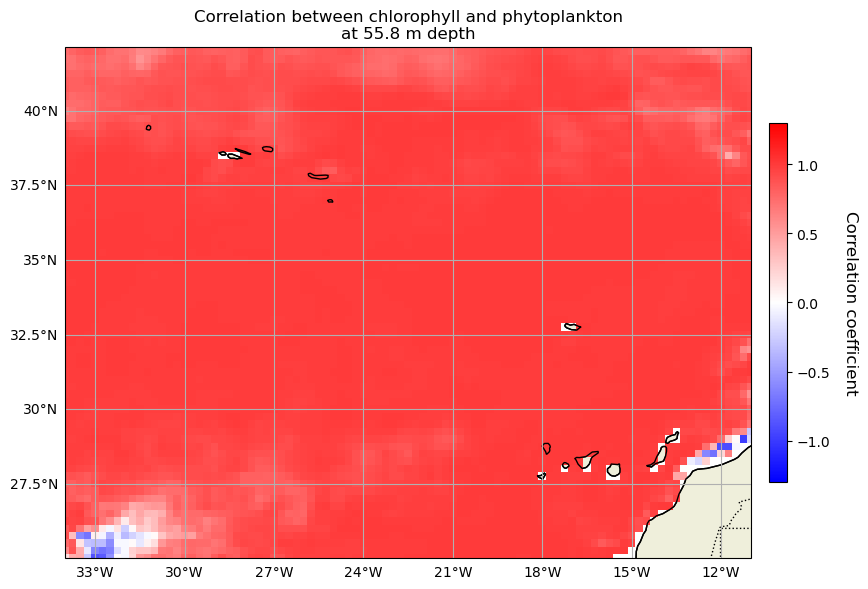

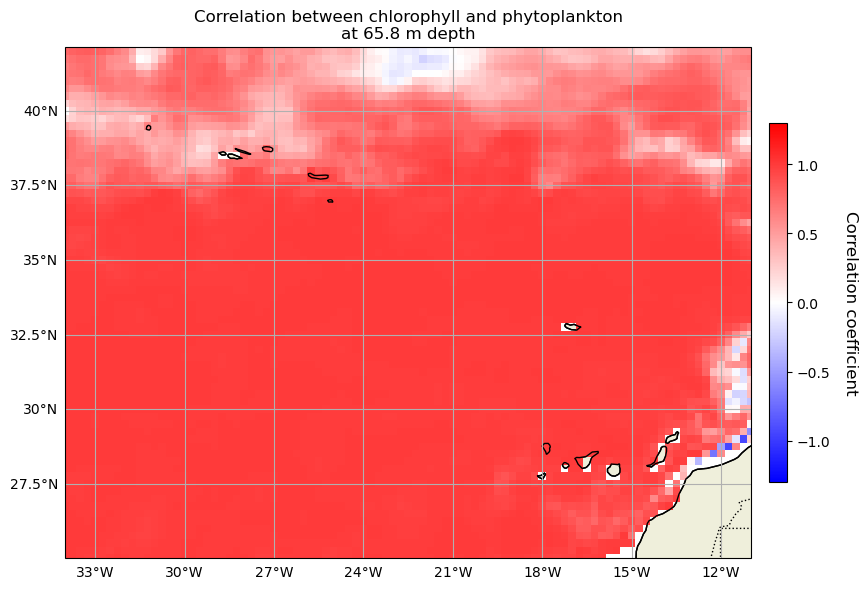

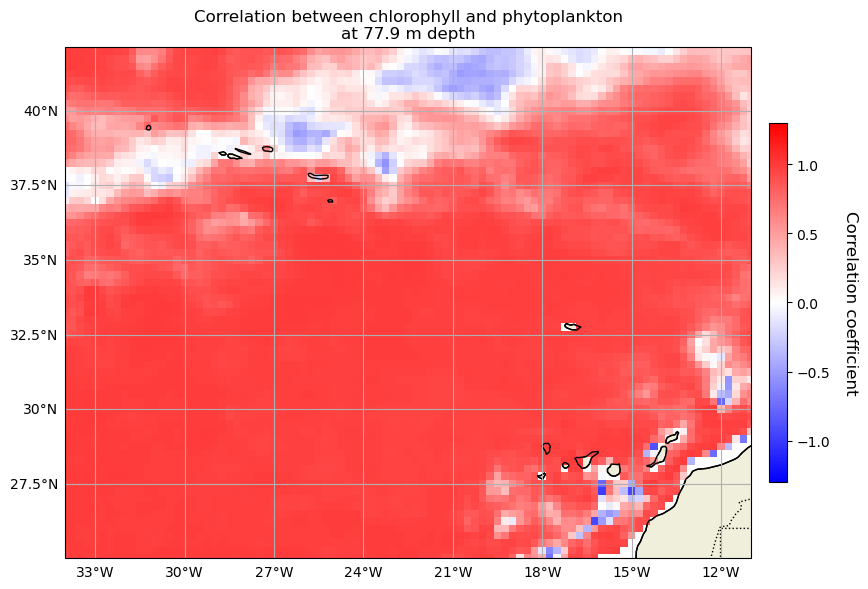

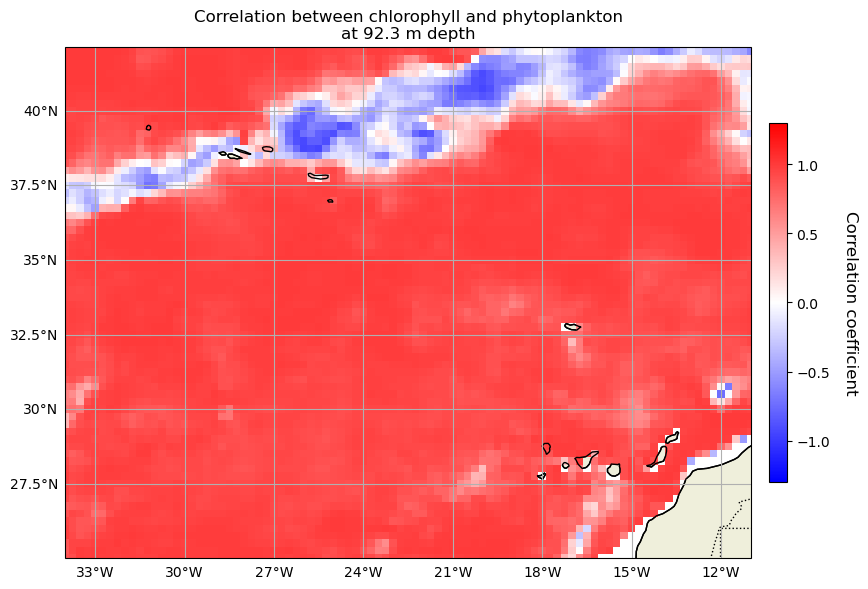

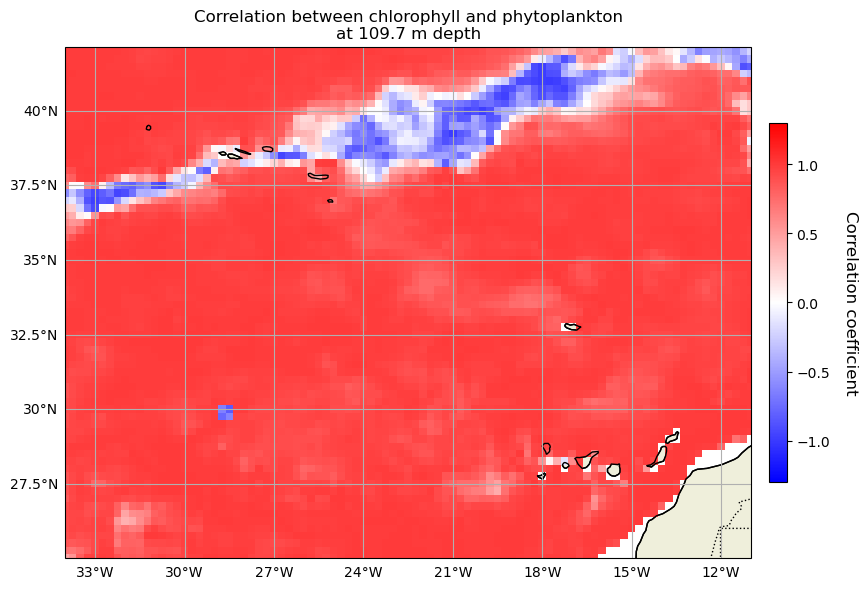

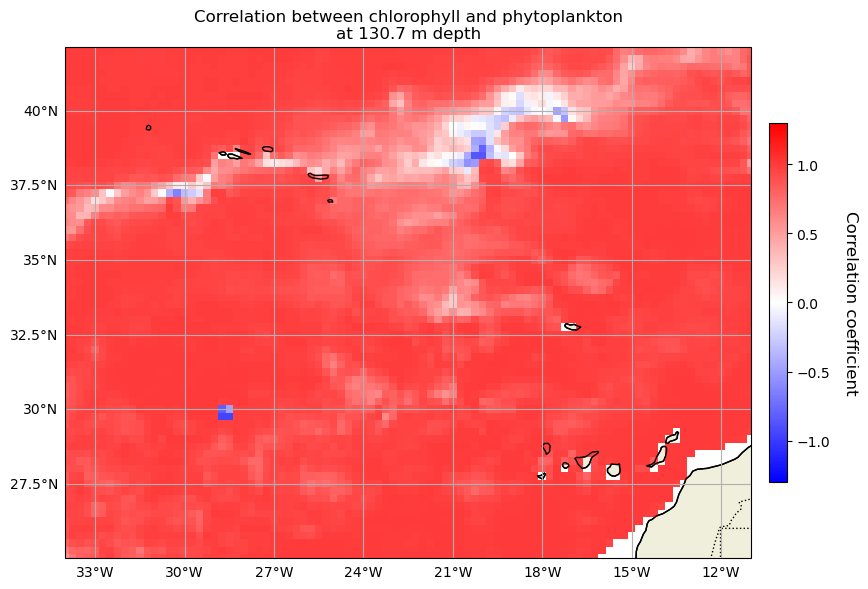

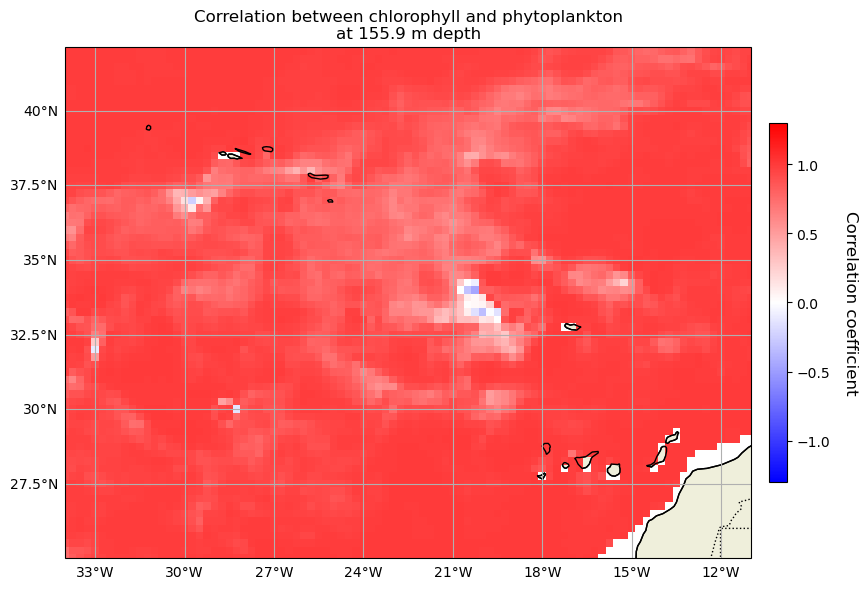

In [ ]:
for d in ds_chl_seas.depth:
    corr_layer = correlation.sel(depth=d, method="nearest")  

    # Plot
    f = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree())
    gl.right_labels = False
    gl.top_labels = False

    # Etichette (facoltative)
    #ax.set_title(f"Correlation between chlorophyll and phytoplankton\nat {d} m depth")
    ax.set_title(f"Correlation between chlorophyll and phytoplankton\nat {float(d):.1f} m depth")
    # PLOT
    im = ax.pcolormesh(
        correlation.longitude,
        correlation.latitude,
        corr_layer,
        cmap='bwr',
        vmin=-1.3,
        vmax=1.3,
        shading='auto'
    )

    # Colorbar
    cbar = f.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label("Correlation coefficient", rotation=270, fontsize=12, labelpad=20)

    plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

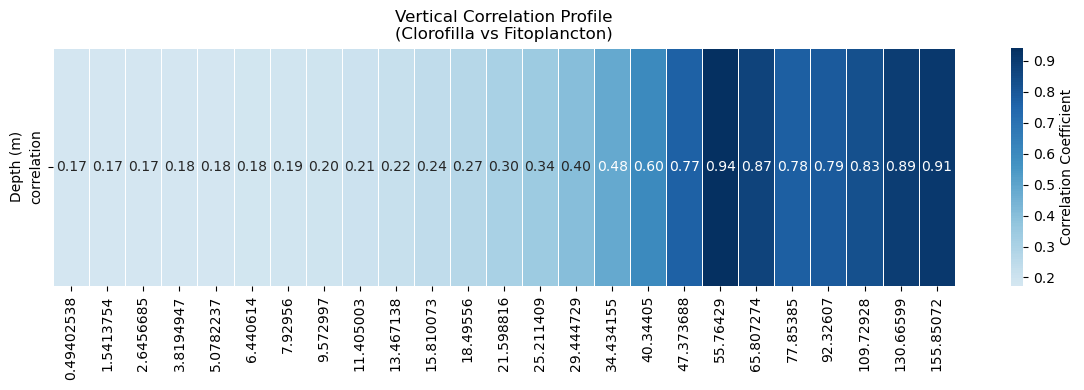

In [ ]:

corr_depth_mean = correlation.mean(dim=["latitude", "longitude"])
df_corr = pd.DataFrame({
    "depth": corr_depth_mean["depth"].values,
    "correlation": corr_depth_mean.values
})

# Plot verticale
plt.figure(figsize=(12, 4))
sns.heatmap(
    data=df_corr.set_index("depth").T,
    cmap="RdBu",
    center=0,
    annot=True,
    cbar_kws={"label": "Correlation Coefficient"},
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Vertical Correlation Profile\n(Clorofilla vs Fitoplancton)")
plt.ylabel("Depth (m)")
plt.xlabel("")
plt.tight_layout()
plt.show()